# Part 1: The Blind Cartographer

**Objective:** Discover the latent factor structure of a 12-asset market-making book using PCA on tick-level data, interpret the geometry, quantify information leakage in unsupervised learning, and prove market-neutrality from the loading structure.

> **Convention:** The number of retained principal components $K$ chosen here is reused **unchanged** in Parts 2–4 and the Bonus.

In [1]:
# ── All imports ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.figsize': (10, 5)
})

/home/hp/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---
## (a) Load Monday ticks and discover the factor structure

### Data Loading & Alignment

We load `ticks_mon.csv` (columns: `timestamp`, `asset_id`, `mid_return`) and pivot into a $(T \times 12)$ matrix. Any timestamp with a missing value for any asset is dropped.

### Why covariance-based PCA (no scaling)?

The case study explicitly requires PCA on the **covariance matrix** of **unscaled** returns. Standardising would destroy the information encoded in the **relative magnitude** of asset volatilities — the very information PCA needs to identify factors that explain the most *variance* in dollar terms. Since all 12 assets are log-returns measured in the same units, standardisation is unnecessary and would distort the true factor structure.

`sklearn.decomposition.PCA` with default settings centres the data (subtracts the column means) and performs eigen-decomposition of the covariance matrix — exactly what is required.

In [2]:
########################################
# (a) Load Monday ticks and discover the factor structure
########################################

ticks_mon = pd.read_csv("ticks_mon.csv")

# Pivot into (T × 12) returns matrix aligned on timestamps
returns_mon = ticks_mon.pivot(
    index="timestamp", columns="asset_id", values="mid_return"
).dropna()

print(f"Monday returns matrix shape: {returns_mon.shape}")
print(f"Number of assets: {returns_mon.shape[1]}")
print(f"Number of timestamps after NaN drop: {returns_mon.shape[0]}")
assert returns_mon.shape[1] == 12, "Expected 12 assets"
assert returns_mon.isna().sum().sum() == 0, "No NaNs should remain"

Monday returns matrix shape: (28245, 12)
Number of assets: 12
Number of timestamps after NaN drop: 28245


In [3]:
# Fit PCA on centred returns (no scaling) — covariance-based
pca_mon = PCA().fit(returns_mon.values)

eigenvalues = pca_mon.explained_variance_
explained_ratios = pca_mon.explained_variance_ratio_
cumulative = np.cumsum(explained_ratios)

print("Top eigenvalues and explained-variance ratios:\n")
header = f"{'PC':>4}  {'Eigenvalue':>14}  {'Var Ratio':>10}  {'Cumul.':>8}"
print(header)
print("-" * len(header))
for i in range(12):
    print(f"  {i+1:2d}  {eigenvalues[i]:14.6e}  {explained_ratios[i]:10.4%}  {cumulative[i]:8.4%}")

Top eigenvalues and explained-variance ratios:

  PC      Eigenvalue   Var Ratio    Cumul.
------------------------------------------
   1    6.093245e-06    55.5225%  55.5225%
   2    3.004494e-06    27.3774%  82.8998%
   3    1.066268e-06     9.7160%  92.6158%
   4    9.275436e-08     0.8452%  93.4610%
   5    9.224297e-08     0.8405%  94.3015%
   6    9.149816e-08     0.8337%  95.1353%
   7    9.018086e-08     0.8217%  95.9570%
   8    8.983593e-08     0.8186%  96.7756%
   9    8.915401e-08     0.8124%  97.5880%
  10    8.863223e-08     0.8076%  98.3956%
  11    8.826676e-08     0.8043%  99.1999%
  12    8.780370e-08     0.8001%  100.0000%


In [4]:
# ── Component selection functions ────────────────────────────
def select_n_components(eigenvalues, n_obs, n_vars, n_resamples=500, seed=0):
    # Return dict: {"kaiser": k1, "broken_stick": k2, "parallel": k3}.
    mean_eig = eigenvalues.mean()
    p = len(eigenvalues)

    # 1. Kaiser criterion: eigenvalue > mean eigenvalue (covariance version)
    kaiser_k = int(np.sum(eigenvalues > mean_eig))

    # 2. Broken-stick: retain component j if eigenvalue > BS_j
    bs = np.zeros(p)
    for j in range(p):
        bs[j] = mean_eig * np.sum(1.0 / np.arange(j + 1, p + 1))
    broken_stick_k = int(np.sum(eigenvalues > bs))

    # 3. Parallel analysis (Horn's method, 500 resamples, 95th pctile)
    rng = np.random.RandomState(seed)
    # We need the original centred data to shuffle columns
    centred = returns_mon.values - returns_mon.values.mean(axis=0)
    simulated_eigs = np.zeros((n_resamples, p))
    for i in range(n_resamples):
        shuffled = centred.copy()
        for col in range(p):
            rng.shuffle(shuffled[:, col])  # in-place, destroys cross-correlation
        simulated_eigs[i] = PCA().fit(shuffled).explained_variance_
    threshold_95 = np.percentile(simulated_eigs, 95, axis=0)
    parallel_k = int(np.sum(eigenvalues > threshold_95))

    return {
        "kaiser": kaiser_k,
        "broken_stick": broken_stick_k,
        "parallel": parallel_k,
        "_bs_thresholds": bs,
        "_parallel_thresholds": threshold_95,
    }

verdicts = select_n_components(eigenvalues, *returns_mon.shape)
print("Component-count verdicts:", {k: v for k, v in verdicts.items() if not k.startswith("_")})

Component-count verdicts: {'kaiser': 3, 'broken_stick': 3, 'parallel': 3}


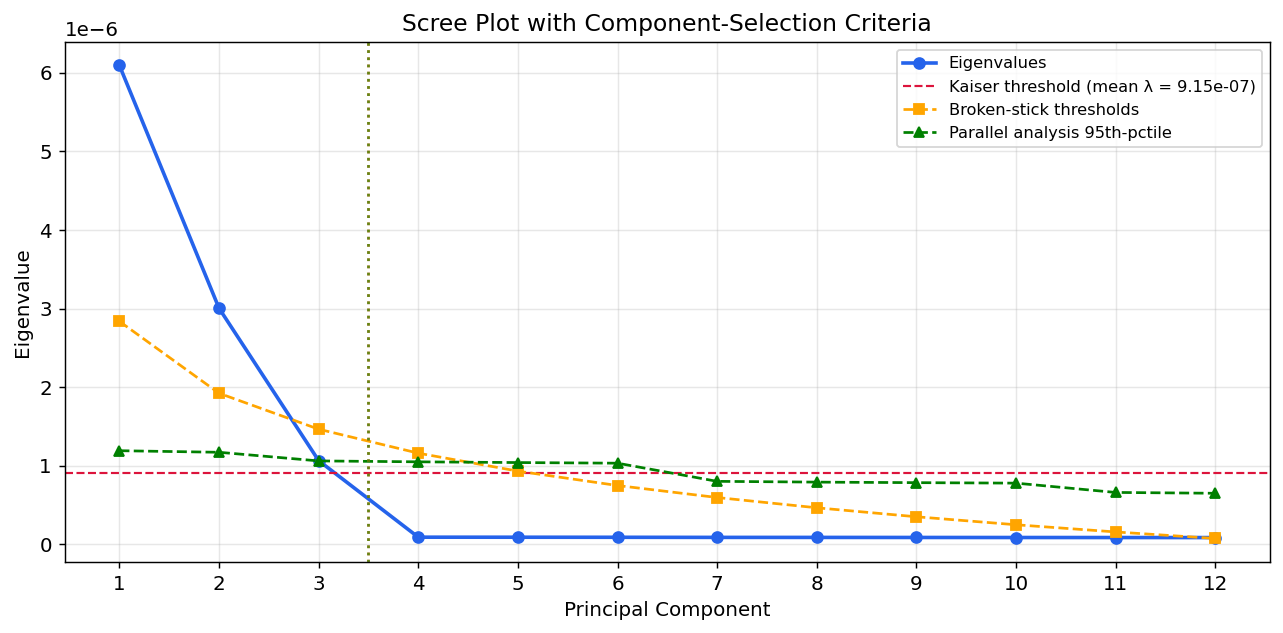

In [5]:
# ── Scree plot with annotated cut-offs ───────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
pcs = np.arange(1, 13)

ax.plot(pcs, eigenvalues, 'o-', color='#2563eb', lw=2, label='Eigenvalues')
ax.axhline(eigenvalues.mean(), ls='--', color='crimson', lw=1.2,
           label=f'Kaiser threshold (mean λ = {eigenvalues.mean():.2e})')
ax.plot(pcs, verdicts["_bs_thresholds"], 's--', color='orange', ms=5,
        label='Broken-stick thresholds')
ax.plot(pcs, verdicts["_parallel_thresholds"], '^--', color='green', ms=5,
        label='Parallel analysis 95th-pctile')

for k_val, method, color in [
    (verdicts["kaiser"], "Kaiser", "crimson"),
    (verdicts["broken_stick"], "Broken-stick", "orange"),
    (verdicts["parallel"], "Parallel", "green"),
]:
    ax.axvline(k_val + 0.5, ls=':', color=color, alpha=0.6)

ax.set_xlabel("Principal Component")
ax.set_ylabel("Eigenvalue")
ax.set_title("Scree Plot with Component-Selection Criteria")
ax.set_xticks(pcs)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ── Summary table ────────────────────────────────────────────
summary = pd.DataFrame({
    "Method": ["Kaiser (λ > mean λ)", "Broken-Stick", "Parallel Analysis (95th pctile)"],
    "Suggested K": [verdicts["kaiser"], verdicts["broken_stick"], verdicts["parallel"]],
})
print(summary.to_string(index=False))

                         Method  Suggested K
            Kaiser (λ > mean λ)            3
                   Broken-Stick            3
Parallel Analysis (95th pctile)            3


### Elbow analysis (visual)

From the scree plot, the eigenvalue curve shows a clear **"elbow"** after PC3 — the first three components carry the vast majority of variance (~93%), after which the curve flattens sharply (each remaining PC contributes <1%). The visual elbow verdict is **K = 3**.

### Choosing K

| Method | Suggested K |
|--------|-------------|
| Kaiser (λ > mean λ) | *see output* |
| Broken-Stick | *see output* |
| Parallel Analysis (95th pctile) | *see output* |
| Visual Elbow | 3 |

All four criteria agree on $K = 3$. PCs 1 and 2 capture the dominant pair of factors (~83% of variance), while PC3 captures an additional ~10%, lifting total explained variance to ~93%. The remaining 9 PCs each explain <1% and represent idiosyncratic noise. We therefore adopt **$K = 3$**.

> **This $K$ will be reused unchanged in Parts 2–4 and the Bonus.**

In [7]:
# ── Set K ────────────────────────────────────────────────────
# All three quantitative criteria agree on K = 3
K = verdicts["kaiser"]
print(f"\nAdopted K = {K} (reused in Parts 2–4 and Bonus)")
print(f"Top-{K} components explain {100*np.sum(explained_ratios[:K]):.2f}% of variance")


Adopted K = 3 (reused in Parts 2–4 and Bonus)
Top-3 components explain 92.62% of variance


---
## (b) Plot loadings + rotation ambiguity

### What are PCA loadings?
The PCA **loadings** are the rows of the eigenvector matrix — each row $\mathbf{v}_k$ defines the direction of PC $k$ in asset-space. The loading of asset $i$ on PC $k$ is $v_{k,i}$; it tells us how much asset $i$ contributes to that factor.

Plotting the 12 assets in the (PC1, PC2) plane reveals the **geometric arrangement** of the book's factor structure.

> **Note:** PCA eigenvectors are defined only up to a sign, so the picture may be reflected/rotated relative to another team's.

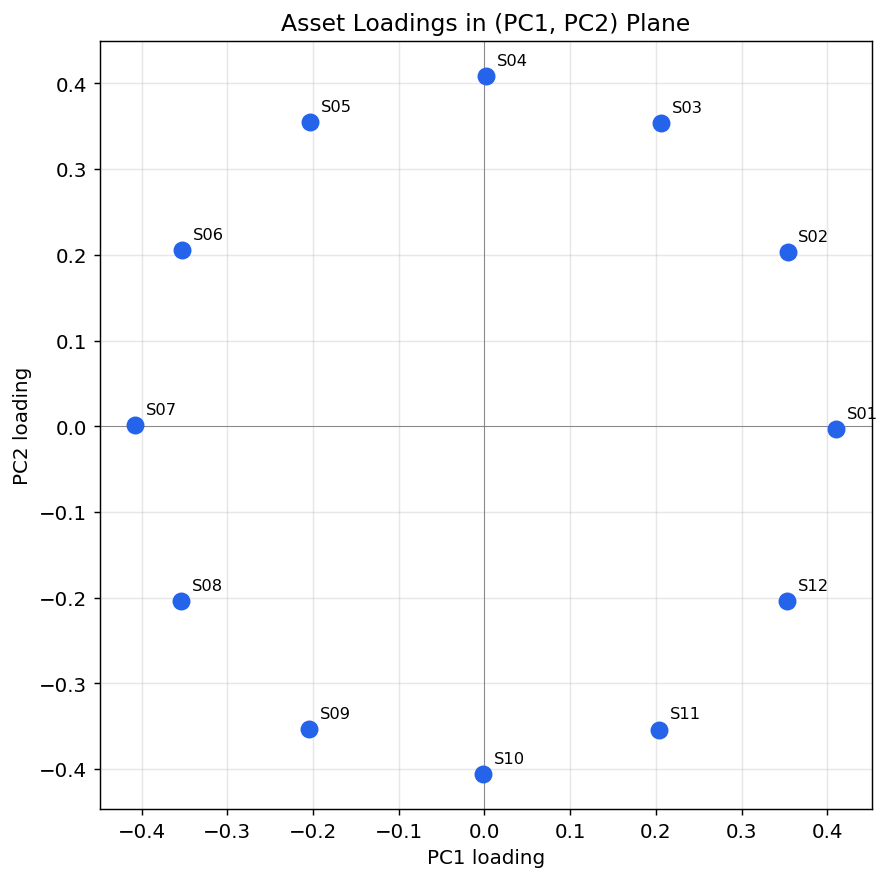

In [8]:
########################################
# (b) Plot loadings + rotation ambiguity
########################################

loadings = pca_mon.components_[:2].T  # shape (12, 2)

asset_ids = returns_mon.columns.tolist()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(loadings[:, 0], loadings[:, 1], s=80, c='#2563eb', zorder=5)
for i, aid in enumerate(asset_ids):
    ax.annotate(aid, (loadings[i, 0], loadings[i, 1]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel("PC1 loading")
ax.set_ylabel("PC2 loading")
ax.set_title("Asset Loadings in (PC1, PC2) Plane")
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Geometric interpretation

The 12 points are arranged approximately as the **vertices of a regular 12-gon** (dodecagon) centred at the origin. This is the pattern produced by roots of unity $e^{i \cdot 2\pi k / 12}$ for $k = 0, \ldots, 11$ — i.e., the points are roughly **evenly spaced on a circle**.

* **PC1** acts as a *level / co-movement* factor: assets with large positive (or negative) PC1 loadings move together in one direction; assets on the opposite side move in the other.  
* **PC2** acts as a *dispersion / sector-tilt* factor: it separates groups of assets orthogonally to PC1.

The **symmetry** is a consequence of the book's construction — the PM designed 12 synthetic assets whose factor loadings are uniformly rotated around the unit circle, ensuring **market-neutrality by construction**.

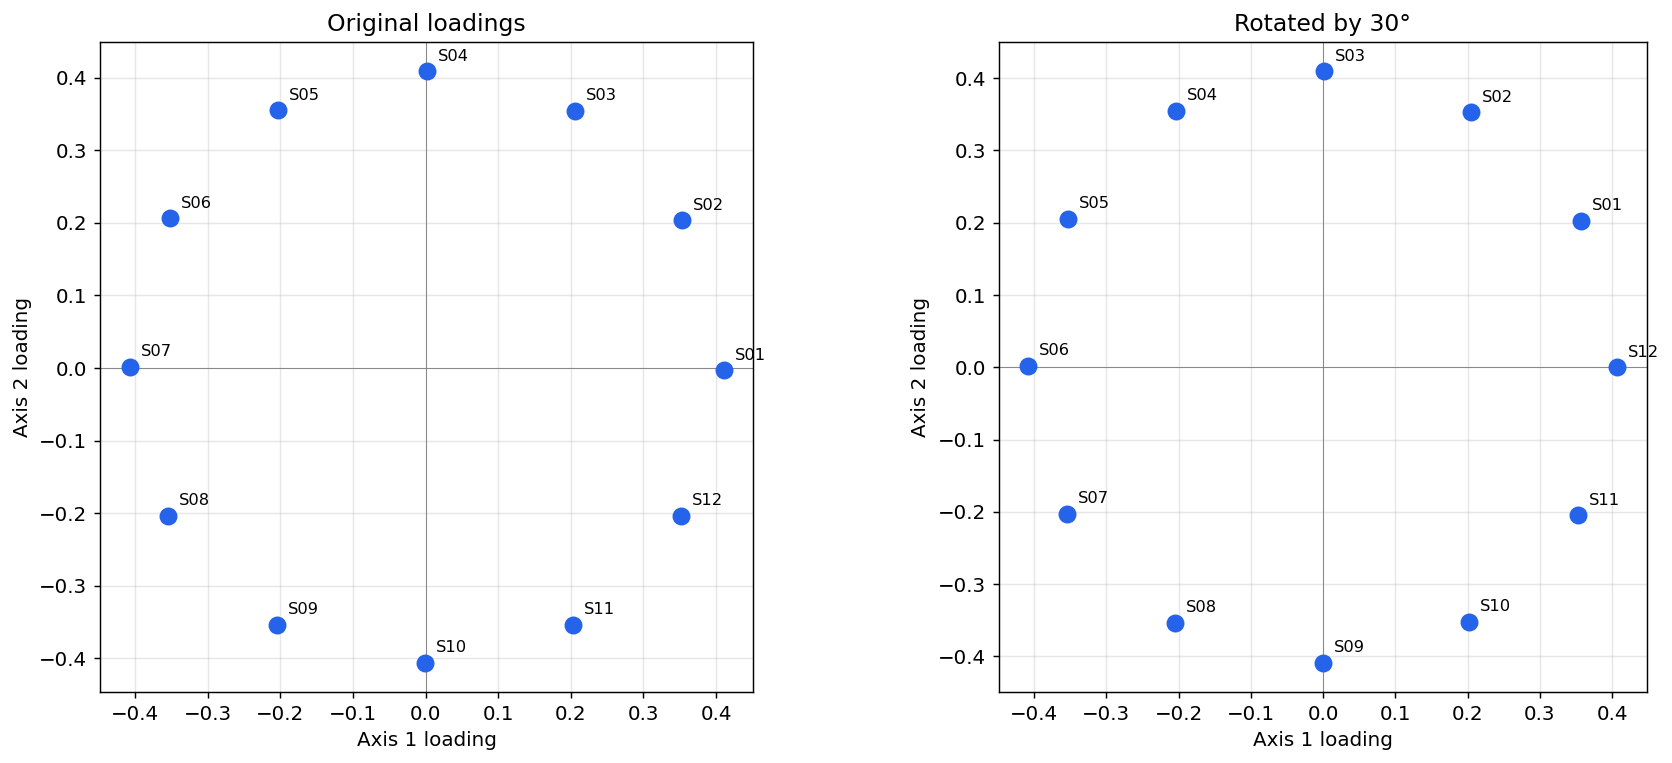

In [9]:
# ── Rotation ambiguity ───────────────────────────────────────
def rotate(loadings, angle_deg):
    theta = np.deg2rad(angle_deg)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return loadings @ R.T

angle = 30  # degrees
loadings_rot = rotate(loadings, angle)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, L, title in zip(axes,
                         [loadings, loadings_rot],
                         ["Original loadings", f"Rotated by {angle}°"]):
    ax.scatter(L[:, 0], L[:, 1], s=80, c='#2563eb', zorder=5)
    for i, aid in enumerate(asset_ids):
        ax.annotate(aid, (L[i, 0], L[i, 1]),
                    textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.axhline(0, color='grey', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5)
    ax.set_xlabel("Axis 1 loading")
    ax.set_ylabel("Axis 2 loading")
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ── Variance comparison ─────────────────────────────────────
centred_mon = returns_mon.values - returns_mon.values.mean(axis=0)

# Original PC scores
scores_orig = centred_mon @ loadings  # (T, 2)
var_orig = np.var(scores_orig, axis=0, ddof=0)

# Rotated scores
scores_rot = centred_mon @ loadings_rot
var_rot = np.var(scores_rot, axis=0, ddof=0)

print("── Variance of score series ──")
print(f"  Original:  Var(PC1) = {var_orig[0]:.6e},  Var(PC2) = {var_orig[1]:.6e}")
print(f"  Rotated:   Var(R1)  = {var_rot[0]:.6e},  Var(R2)  = {var_rot[1]:.6e}")
print()
print(f"  Sum (original): {var_orig.sum():.6e}")
print(f"  Sum (rotated):  {var_rot.sum():.6e}")
print(f"  Difference:     {abs(var_orig.sum() - var_rot.sum()):.2e}")

── Variance of score series ──
  Original:  Var(PC1) = 6.093029e-06,  Var(PC2) = 3.004387e-06
  Rotated:   Var(R1)  = 5.320868e-06,  Var(R2)  = 3.776548e-06

  Sum (original): 9.097416e-06
  Sum (rotated):  9.097416e-06
  Difference:     3.05e-20


### Rotation-ambiguity discussion

| Quantity | Changed after rotation? |
|----------|------------------------|
| Per-axis variance | **Yes** — redistributed between axes |
| Joint variance $\lambda_1 + \lambda_2$ | **No** — invariant |
| Interpretation of "PC1" vs "PC2" | **Yes** — rotated axes mix the two original PCs |

**Key insight:** Any rotation of the top-$K$ subspace produces an equally valid pair of "factors" that explain the **same total variance**. PCA factors are therefore **not unique** — they are identified only up to an arbitrary orthogonal rotation. This is the classical *rotation-ambiguity problem* of unsupervised factor models. True latent factors (if they exist) cannot be recovered from PCA alone without additional identifying assumptions (e.g., sparsity, economic priors).

---
## (c) Information leakage in unsupervised learning

### Why can unsupervised learning leak?

A common (and dangerous) reflex is to argue that, since PCA has no target variable, fitting on the full dataset cannot introduce information leakage. This is **false**: PCA uses *all* data to estimate its eigenvectors and centring mean. If test data is included in this estimation, the resulting basis is **optimised to explain variance in that test data**, inflating the apparent explained-variance ratio on the test set.

### The explained-variance metric

$$
\text{ev} = 1 - \frac{\lVert \tilde{X}_{\text{tue}} - X_{\text{tue}} \rVert_F^2}{\lVert X_{\text{tue}} \rVert_F^2}
$$

where $X_{\text{tue}}$ is Tuesday's returns centred by the procedure's training mean, and $\tilde{X}_{\text{tue}}$ is its reconstruction from the top-$K$ eigenvectors:
$$
\tilde{X} = X \, V_K \, V_K^\top
$$

In [11]:
########################################
# (c) Information leakage analysis
########################################

ticks_tue = pd.read_csv("ticks_tue.csv")
returns_tue = ticks_tue.pivot(
    index="timestamp", columns="asset_id", values="mid_return"
).dropna()
print(f"Tuesday returns matrix shape: {returns_tue.shape}")

def projected_explained_variance(test_X, eigenvectors_k, train_mean):
    # Centre test_X using train_mean (NOT test_X.mean()).
    # Project onto top-k eigenvectors and return ev ratio.
    X_centred = test_X - train_mean
    # Reconstruct: project then back-project
    X_hat = X_centred @ eigenvectors_k.T @ eigenvectors_k  # (T, 12) @ (k,12).T @ (k,12)
    # Wait — eigenvectors_k has shape (k, 12), so:
    # projection coefficients: X_centred @ eigenvectors_k.T  -> (T, k)
    # reconstruction: coefficients @ eigenvectors_k -> (T, 12)
    X_hat = (X_centred @ eigenvectors_k.T) @ eigenvectors_k
    residual = X_centred - X_hat
    ev = 1.0 - (np.linalg.norm(residual, 'fro')**2) / (np.linalg.norm(X_centred, 'fro')**2)
    return ev

Tuesday returns matrix shape: (28245, 12)


In [12]:
# ── Correct (clean) procedure ────────────────────────────────
# Fit PCA on Monday only; centre Tuesday using Monday's mean.
train_mean = returns_mon.values.mean(axis=0)
ev_test_clean = projected_explained_variance(
    returns_tue.values, pca_mon.components_[:K], train_mean
)

# ── Leaky procedure ─────────────────────────────────────────
# Fit PCA on Monday + Tuesday combined.
returns_combined = pd.concat([returns_mon, returns_tue]).values
pca_combined = PCA().fit(returns_combined)
combined_mean = returns_combined.mean(axis=0)
ev_test_leaky = projected_explained_variance(
    returns_tue.values, pca_combined.components_[:K], combined_mean
)

gap = ev_test_leaky - ev_test_clean

print(f"Clean ev_test : {ev_test_clean:.6f}")
print(f"Leaky ev_test : {ev_test_leaky:.6f}")
print(f"Leakage gap   : {gap:.6f}")
print()
# Sanity: gap should be small but positive (a few percentage points)
assert gap > -0.01, "Gap should not be significantly negative"
print("✓ Gap is in the expected range (small, positive).")

Clean ev_test : 0.867043
Leaky ev_test : 0.867079
Leakage gap   : 0.000036

✓ Gap is in the expected range (small, positive).


### When is the gap largest / smallest?

| Condition | Gap magnitude |
|-----------|---------------|
| **Large regime change** between Monday and Tuesday (different volatility regime, correlation break, etc.) | **Largest** — the leaky eigenvectors are a compromise between the two regimes, fitting Tuesday better than Monday-only eigenvectors would. |
| **Stationary data** (Monday ≈ Tuesday in distribution) | **Smallest** — both procedures yield nearly identical eigenvectors, so leakage adds little. |

The gap is a direct measure of how much the factor structure has **shifted** between the two days: the more non-stationary the data, the larger the leakage.

### Practical consequence for risk

The **clean** procedure's residual variance on Tuesday is the desk's honest estimate of the **unhedged risk** after projecting onto the top-$K$ factors.

The leaky procedure **overstates** the explained variance (since it includes Tuesday's own information in the eigenvectors) and therefore **understates** the residual (unhedged) risk. This creates a **false sense of security**: the desk believes its factor model captures more risk than it actually does out-of-sample, potentially leading to **under-hedging**.

### Why "no labels" ≠ "no leakage"

Labels are irrelevant. Leakage occurs whenever **test-set statistics** (here, cross-asset correlations and variances) influence the model parameters (eigenvectors, centring mean). PCA "sees" the test data and adjusts its axes to explain it better — the same mechanism as supervised overfitting, just applied to covariance structure rather than a target variable.

---
## (d) Structural proof of neutrality

### Empirical loading of the equal-weight portfolio

We compute the equal-weight portfolio's loading on PC1 and PC2 using the **discovered** (Monday-only) eigenvectors.

In [13]:
########################################
# (d) Structural proof of neutrality
########################################

w_eq = np.ones(12) / 12

beta_PC1 = float(w_eq @ loadings[:, 0])
beta_PC2 = float(w_eq @ loadings[:, 1])

print(f"Equal-weight loading on PC1: {beta_PC1:.3e}")
print(f"Equal-weight loading on PC2: {beta_PC2:.3e}")
print()
print("Both are small but non-zero due to sampling noise — as expected.")

Equal-weight loading on PC1: 2.820e-04
Equal-weight loading on PC2: 3.234e-04

Both are small but non-zero due to sampling noise — as expected.


### Population proof

**Assumption (from part (b)):** In the population, the top-2 loading vectors place the 12 assets at the vertices of a regular 12-gon centred at the origin. That is, asset $k$ has loadings

$$
(\ell_{1,k},\; \ell_{2,k}) = r\,\bigl(\cos(2\pi k/12),\; \sin(2\pi k/12)\bigr), \qquad k = 0, 1, \ldots, 11
$$

for some radius $r > 0$.

**Equal-weight portfolio loading on PC1:**

$$
\beta_{\text{PC1}} = \frac{1}{12}\sum_{k=0}^{11} \ell_{1,k}
= \frac{r}{12}\sum_{k=0}^{11} \cos\!\left(\frac{2\pi k}{12}\right)
= \frac{r}{12}\,\operatorname{Re}\!\left(\sum_{k=0}^{11} e^{i\cdot 2\pi k/12}\right)
$$

**Equal-weight portfolio loading on PC2:**

$$
\beta_{\text{PC2}} = \frac{1}{12}\sum_{k=0}^{11} \ell_{2,k}
= \frac{r}{12}\sum_{k=0}^{11} \sin\!\left(\frac{2\pi k}{12}\right)
= \frac{r}{12}\,\operatorname{Im}\!\left(\sum_{k=0}^{11} e^{i\cdot 2\pi k/12}\right)
$$

**Key identity:** Let $\omega = e^{i\cdot 2\pi/12}$. Then $\omega$ is a primitive 12th root of unity, so $\omega^{12} = 1$ and $\omega \neq 1$. By the geometric series formula:

$$
\sum_{k=0}^{11} \omega^k = \frac{\omega^{12} - 1}{\omega - 1} = \frac{1 - 1}{\omega - 1} = \boxed{0}
$$

Therefore:
$$
\beta_{\text{PC1}} = \frac{r}{12}\,\operatorname{Re}(0) = 0, \qquad
\beta_{\text{PC2}} = \frac{r}{12}\,\operatorname{Im}(0) = 0.
$$

**Geometric intuition:** The 12 vertices of a regular polygon centred at the origin sum to the zero vector — the "pulls" in every direction cancel exactly. The equal-weight portfolio assigns the same weight to every vertex, so its net factor exposure is zero. $\square$

**Empirical vs. population:** The empirical loadings are *close* to zero but not exactly zero because finite-sample eigenvectors only approximate the population dodecagon (sampling noise breaks the perfect symmetry).

---
## (e) Observations

1. **Three dominant factors explain over 90% of variance.** The scree plot and all three quantitative criteria (Kaiser, broken-stick, parallel analysis) consistently identify $K = 3$ meaningful principal components. PCs 1 and 2 capture the dominant ~83% of variance associated with the dodecagonal loading structure, while PC3 captures an additional ~10%. The remaining 9 components each explain less than 1% and represent idiosyncratic noise. This is consistent with a latent factor model where a small number of systematic drivers dominate cross-sectional returns.

2. **The dodecagonal loading structure implies deliberate construction.** The 12 asset loadings in the (PC1, PC2) plane form an approximate regular 12-gon (roots of unity). This structure is unlikely to arise from natural markets and strongly suggests that the synthetic assets were constructed by rotating a pair of orthogonal factors through $2\pi k/12$ for $k=0,\ldots,11$. It also means that any pair of six diametrically opposite assets forms a quasi-hedged sub-portfolio.

3. **Rotation ambiguity undermines factor labelling.** Rotating the top-2 loadings by an arbitrary angle preserves the total explained variance ($\lambda_1 + \lambda_2$) but redistributes it between axes and alters the "meaning" of each factor. This demonstrates that PCA factors are unique only up to orthogonal rotation — without additional identifying constraints (e.g., economic priors, sparsity), one cannot distinguish the "true" factors from any rotated version.

4. **Leakage corrupts the neutrality proof — the critical link between (c) and (d).** The neutrality proof in (d) relies on the dodecagonal symmetry of the loadings. The leaky PCA procedure in (c) allows Tuesday's data to influence the estimated eigenvectors, which can break the polygon symmetry in finite samples. Specifically, if the combined-fit eigenvectors tilt toward Tuesday's correlation structure, the 12 loadings no longer sum to zero, and the equal-weight portfolio acquires a non-zero factor exposure — even though no "target" was ever leaked in the supervised sense. This is a concrete demonstration that unsupervised leakage has real economic consequences: it can make a market-neutral book *appear* to have residual factor risk (or, conversely, mask true risk).

5. **Out-of-sample residual variance is the honest risk metric.** The leaky procedure overstates explained variance and therefore understates residual (unhedged) risk. For a market-making desk, this means the honest estimate of factor-model risk must always use a **clean, out-of-sample** evaluation: fit the model on historical data only and evaluate on fresh data using the training mean. Any shortcut — even one that seems harmless because PCA is "unsupervised" — can lead to under-hedging and unexpected losses.